### Build chatbot

In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [4]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

In [5]:
graph_builder

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
# from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chat_models import init_chat_model


# llm = ChatGroq(model="whisper-large-v3-turbo")
llm = ChatGoogleGenerativeAI(model='gemini-3.8-flash')
llm

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={}, google_api_key=SecretStr('**********'), model='gemini-3.8-flash', temperature=None, client=<google.genai.client.Client object at 0x0000027CD4E2CC20>, default_metadata=(), model_kwargs={})

In [14]:
# llm = init_chat_model("qroq:meta-llama/llama-prompt-guard-2-22m")
# llm

In [7]:
### Node Functionality
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)

## Add Node
graph_builder.add_node("llmchatbot", chatbot)

## Add Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## Compile the graph
graph = graph_builder.compile()

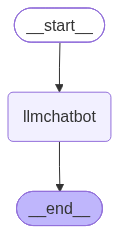

In [9]:

## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response = graph.invoke({"messages": "Hi"})

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [11]:
response["messages"][-1].content

[{'type': 'text',
  'text': 'Hello! How can I help you today?',
  'extras': {'signature': 'EtEBCs4BAWkUfROkg9XDi2Fsidv8oRQJlwTXACORB2Am3124HV2Pb6i9WgxDyyXBhrGg/vaos+Fb4v+IdtBsmiLEbEW/1VEtx3Eq8wqoVbGVcLunoEPjr7UunH4WarIhj3sm8Rmb05PoalKLtIxwudjuI22QEXe70cMqeW8y+4JXFiBJicIQgyP13ODf4F+nZn8IqbJkiF5SOZzYkFJ7m8CBpPYY9hW9A61mCRaykontGXNRRLGQdVMKor8qtfmPlH9Et2L70KGiRtswfFE2GLfB0Cw='}}]

In [12]:
for event in graph.stream({"messages": "Hi how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

[{'type': 'text', 'text': "Hello! I'm doing well, thank you for asking. How are you doing today? How can I help you?", 'extras': {'signature': 'EssECsgEAWkUfRNByLbPABM7IzjHzVmWz1k4mmW3e6f1xAJ+Lup4oJuin2jqE2tst4wXIuN3k6ZBaJ9lJNfcQ0CZVAJ4ySqfUWLqrn1bKFncpbO9cjtuhXdwb+E8tw4nOrqq8FxBiAjm+/t3BhSkbLBTeHDyYtXwkbuhuHW1zqJIvz0H+QGkXbnyVND5OXSw8G3iHp6LsZTr5HxbntotKx1rL/L4tibSb6FGesMUCouykz3pKCY4LbCnu7JoFyAeoGo2i4UTkbiXJoq+IMqldx+2qJ/giDlkkeEZN7Zdbv7D8ShFwJ7Wt3101AAqEsnkc/pMDOCVzqb4CBH+18RrqdyuWcb6wdVmOsE06DO78GVSbTC42ZbT7ThEMxcNqUJBblpEDyyJdpNT/AIcZ6zdXMnJiF6ZHt9O9a6MSZRa+cvspCIG5rygIqoAco2IqDPtOAsd2DTe/MyPXGCYANDSFl8yARYjBZg4sayM/HTuFvi6VDSp9K6RnfkgSnGc4AbFY8eKNgIEdloTdMHr6JGYwS0ls0Dwri2J30bDfo4UamjdQ+0/gMVwO2BYsHtJPMtoHP+3TvOhUrW3R/3q6va7cH1rGsB4MZyIXYsi8dXONSXI7mSnozx1eTHCoFRYg8yRnDXUTEa27bNFdJW1UJUdPeM0FBu0h2/gB1fsOBBUR1N56Nq0cQ0jhB6ejU+vvRaIocHKU4RbPLPBSl8P9Zdi8xivbqsb8JLWp1QJQTFCXqxDz9t1EXizShNk2h5PPskrn1HD2m2HjrNzRoHDWjM='}}]


### Chatbot With Tool

In [21]:
# # from langchain_tavily import TavilySearch
# from langchain_community.utilities import TavilySearchAPIWrapper

# # Leave the API key blank—Tavily's server will automatically route it to the free keyless tier
# search = TavilySearchAPIWrapper(tavily_api_key="")
# response = search.results("What is the latest tech news today?")
# print(response)
# # tool = TavilySearch(max_results=2)
# # tool.invoke("What is langgraph?")

### Custom Tools

In [13]:
from langchain.tools import tool

In [14]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: First int
        b: Second int
    """
    return a * b

In [15]:
tools = [multiply]

In [16]:
llm_with_tool = llm.bind_tools(tools)

In [17]:
llm_with_tool

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={}, google_api_key=SecretStr('**********'), model='gemini-3.8-flash', temperature=None, client=<google.genai.client.Client object at 0x00000207893DABA0>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a and b.\n\nArgs:\n    a: First int\n    b: Second int', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}]}, config={}, config_factories=[])

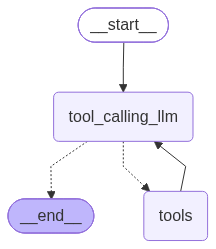

In [26]:
### Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


### Node Definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")

### Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
response = graph.invoke({"messages": "What is 2 times 5?"})

In [28]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 times 5?
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (call_533126)
 Call ID: call_533126
  Args:
    b: 5
    a: 2
================================= Tool Message =================================
Name: multiply

10
================================== Ai Message ==================================

[{'type': 'text', 'text': '2 times 5 is 10.', 'extras': {'signature': 'EpcBCpQBAWkUfRMYNv9vtBqRO/fnEpR0K2S0FPqAVWT8Tcq6pnbgvQ4gg37Di/GfeVQhnpt+RMcmhBZULK0P5UjzrZpSyJWktPdB1UFxKvNyhu0UD6qFqnLW1PLKESH8sHQm0PVOHaD8EQtNx5SnNjus3C0Vl5jlCD4k0CpyQG6PkBE/Tmwp/GEWB+GWzF63XBR6veUbaBWEig=='}}]


### ReAct Agent Architecture

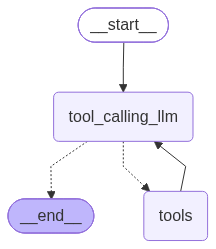

In [31]:
### Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


### Node Definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")

### Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
response = graph.invoke({"messages": "What is 2 times 5?"})

In [33]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 times 5?
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (call_398467)
 Call ID: call_398467
  Args:
    b: 5
    a: 2
================================= Tool Message =================================
Name: multiply

10
================================== Ai Message ==================================

[{'type': 'text', 'text': '2 times 5 is 10.', 'extras': {'signature': 'EpgBCpUBAWkUfROosVpWWX3X0aOpicSkmN8SnLeCf2D6OKoBgZsBR8h4T0dCY5/oTAinCJzysnDLva8dIJyAY+uniBK96Lbb2bdyFLechkMvQDIORhF8tPK/7iQUOPAx8x5v5xHIzmIoTTYihfCeWihpx3XCblp4Vsw7VtG5cImF1TmKIAVn5GE5qQBDqOhLUQJsgxULriuQWOo='}}]


### Adding Memory In Agentic Graph

In [34]:
response = graph.invoke({"messages": "Hello my name is Asmare"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Asmare
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hello Asmare! Nice to meet you. How can I help you today?', 'extras': {'signature': 'EvQBCvEBAWkUfRP6XrBun8yBnKQ7rTSq/PMaigajeLfiI/xFWQeOzZgI6S9VIHMuwA1JC7xFN5SoHlDCPZjfkYlKDCNS5tvtL2TQ0AU5foMAanOn/+fFL6Vfkt2r0rfQYuJW79sMnUFxE3zecP7YTbpSkxOnmGtk1GkquDQH6knMJoEbVt+ACn0/n+8O7glzIgFBp3wcx1pdGHCNamioqGFKenGAUQQFtD1LnYP8qF6MBgEJsZ29CEN1X8MhozqsD79bQhwDOZ1bmVtiA6lbmVlAvl/vUKgBi0cfmIB6LfgK9nEMGaXekQXfhRFGfaAD4ZmIgVJFNA=='}}]


In [35]:
response = graph.invoke({"messages": "What is my name?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

[{'type': 'text', 'text': "I don't know your name, as you haven't shared it with me yet. What should I call you?", 'extras': {'signature': 'EsUCCsICAWkUfRN9YyTNz240uEftgJmQMWeU3d+piqlBhXealx5O71eL+Vh2oJFR6GO5mhN2+23FKhSH+5k0zYA/f0e2gNvPy/SShVFJLZlVGgzf/8qI9T5BwUDQS/HIIdK/eHWli38hvePaY8pyZoNkwqlcIvC53qlC6T/GfOz68FKajqj55yXYq94BeiW5ifFlM4mBWc0CXkCr33uV7794t6cB8olrjGZr+yWvEluc4DqykbjTiUvFV+mXb9oINxsUnj5OFp++TSNZOcNxwA0MtUDDtzGupbqt00FcFZmGnKVyM1pY6GsYh4opZJfiYa4cbTWd8yDpmSjfoqNqHoBsv15VK2wIXQ+Iaw9+obqo5zc5t/bWWu4gag/VB+RjDwFFpfw4SctUN3pYY4LZfcux9XjIYbXDZuE1PdEguj/f5mFgiYINVg=='}}]


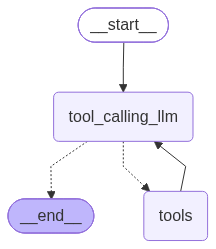

In [36]:
### Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver


memory = MemorySaver()
### Node Definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")

### Compile the graph
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
config = {"configurable": {"thread_id": "1"}}
response =graph.invoke({"messages": "Hi my name is Asmare."}, config= config)
response

{'messages': [HumanMessage(content='Hi my name is Asmare.', additional_kwargs={}, response_metadata={}, id='b04a395d-4092-4fde-9a0a-75b2b745168c'),
  AIMessage(content=[{'type': 'text', 'text': 'Hello Asmare! Nice to meet you. How can I help you today?', 'extras': {'signature': 'EroBCrcBAWkUfROo8DmEFm6UYfIi9jzvywz9LAm0bjhQrk3jBx2CDnGiLttyl8ocBkyR6bYE49umQKZevPNWjcR+BMJqXR200b6uHZsVZTkHe1mRthAlfAKFA3IqzLlsxWZ4YyiRvap1k25dqMEk0dWBksH0u/m0yWbennmXWV6vGUvImpiNc2reB1HqawfvpGQxVE/HhzKEugvN4ya2Y81eZikXlccIiNCYYq8wAOzhfIa0aCr50SML7fWw'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.8-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0b9dd-679b-7912-a30d-3a57b872f239-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 31, 'total_tokens': 106, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 15}})]}

In [41]:
response["messages"][-1].content

[{'type': 'text',
  'text': 'Hello Asmare! Nice to meet you. How can I help you today?',
  'extras': {'signature': 'EroBCrcBAWkUfROo8DmEFm6UYfIi9jzvywz9LAm0bjhQrk3jBx2CDnGiLttyl8ocBkyR6bYE49umQKZevPNWjcR+BMJqXR200b6uHZsVZTkHe1mRthAlfAKFA3IqzLlsxWZ4YyiRvap1k25dqMEk0dWBksH0u/m0yWbennmXWV6vGUvImpiNc2reB1HqawfvpGQxVE/HhzKEugvN4ya2Y81eZikXlccIiNCYYq8wAOzhfIa0aCr50SML7fWw'}}]

In [42]:
response =graph.invoke({"messages": "What is my name?"}, config= config)
response["messages"][-1].content

[{'type': 'text',
  'text': 'Your name is Asmare!',
  'extras': {'signature': 'EvgBCvUBAWkUfRP2dDwbEpfplc7dWZxd8aLTHzHb04NpRWCDhlAsk8jvh8oH5rezON9FIyKK17/L1xEom8dUg1zrzrr6MWa4RjubnkYJ+zQMmn1ndHjbnVbqCRo8rRz06pOLw8/ANZPMnZSDo2q2T9Gj2seWl8bjBNTP7hFCcNtTAtFObp8IKf5OogzyMNp/bqORKYALzOe9r1weUtA6h4GE2YINi82SPRblvZXcXtBii4MqoXpWoWQ965iUTynz6ir4MYWbGwACaOvRUPiaIZ/Vp6/ajUMueeXc0HttyB1ypVALXjoQAnlFRUFW4xP3SmI1BTA+Dt9kc5Q='}}]

### Streaming 

In [8]:
from langgraph.checkpoint.memory import MemorySaver


memory = MemorySaver()

In [9]:
def superbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

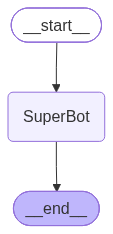

In [10]:
graph = StateGraph(State)

## Node
graph.add_node("SuperBot", superbot)

## Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

### Streaming

Methods: stream() and astream()
 - These methods are sync and async methods for streaming back results

Additional parameters in streaming modes for graph state
 - Values: This streams the full state of the graph after each node is called.
 - Updates: This streams updates to the state of the graph after each node is called.

In [11]:
config = {"configurable": {"thread_id": "3"}}
for chunk in graph_builder.stream({"messages":"Hi my name is Asmare and I like football."}, config=config, stream_mode="updates"):
    print(chunk)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'SuperBot': {'messages': [AIMessage(content=[{'type': 'text', 'text': "Hi Asmare! It's great to meet you. \n\nFootball is an incredible sport! Are you a fan of association football (soccer) or American football? \n\nEither way, who is your favorite team or player to watch?", 'extras': {'signature': 'EtoICtcIAWkUfRNqpSFP9uFx7KJcJZKct4GubDZ5vnP1edx9CfY8nV4u8i6VXJMSczQ2HwSQwJYjkGUlCl4TIFAj/k9fqKoY4kMn32Kpd6mYCIiNqtFadmvXsDtkjrhTvw7mtftROA84QcfeWqc8sG/OMVbQ0Tv3Ai0QLawUhVA7p+1toS43PXVoFpOu3V+m2FZfzNsFP3SscMlO+scwx1GFiIHXqpf4FSXo8ILQHSDeV38/T4ve0FETj66Pu2ahQhgby/VTnx7YuQwXaSt4db8i0kziFis1lmHfpO8Rmmjs7HwMIwZ5KoXfsHlNnswUdcBAJimvl7VtC64DRPrjNnRs8fT2rQxYdQkn47N8osaCrZd/mW+vt8OlSGd2nmZMuEgDhA5gLpym+ygrqKwSL9a/4eLXKwPsN238C0vJlhtj9oe9ZWkf00D6rcMJ4bqMVK8OtCSqhx1O9a7VhCxFU2V6yr2a5PhTqclplhkvqf38SPgJjry+9OjOe8cFyT7AUXj4apF/Uu0agvlRiukOpgZ2YJUSK8PRZ5QFtndXbpxissSK2nMATZnM8kLIAf4Gku6225yEFeydGi65o1x68ibJTE79cOAEm1SKiEigaA90NrMfeW+htp8j57Z9CbcTlZsxK4Nm1Vbc2OudNYKk7qMC6kFu5GxIpYgluXtVCz7MjSSv/8DP4BJbza

In [12]:
config = {"configurable": {"thread_id": "3"}}
for chunk in graph_builder.stream({"messages":"Hi my name is Asmare and I like football."}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is Asmare and I like football.', additional_kwargs={}, response_metadata={}, id='ba2705d6-5df5-412e-9a11-1e3c3e6b555d'), AIMessage(content=[{'type': 'text', 'text': "Hi Asmare! It's great to meet you. \n\nFootball is an incredible sport! Are you a fan of association football (soccer) or American football? \n\nEither way, who is your favorite team or player to watch?", 'extras': {'signature': 'EtoICtcIAWkUfRNqpSFP9uFx7KJcJZKct4GubDZ5vnP1edx9CfY8nV4u8i6VXJMSczQ2HwSQwJYjkGUlCl4TIFAj/k9fqKoY4kMn32Kpd6mYCIiNqtFadmvXsDtkjrhTvw7mtftROA84QcfeWqc8sG/OMVbQ0Tv3Ai0QLawUhVA7p+1toS43PXVoFpOu3V+m2FZfzNsFP3SscMlO+scwx1GFiIHXqpf4FSXo8ILQHSDeV38/T4ve0FETj66Pu2ahQhgby/VTnx7YuQwXaSt4db8i0kziFis1lmHfpO8Rmmjs7HwMIwZ5KoXfsHlNnswUdcBAJimvl7VtC64DRPrjNnRs8fT2rQxYdQkn47N8osaCrZd/mW+vt8OlSGd2nmZMuEgDhA5gLpym+ygrqKwSL9a/4eLXKwPsN238C0vJlhtj9oe9ZWkf00D6rcMJ4bqMVK8OtCSqhx1O9a7VhCxFU2V6yr2a5PhTqclplhkvqf38SPgJjry+9OjOe8cFyT7AUXj4apF/Uu0agvlRiukOpgZ2YJUSK8PRZ5QFtndXbpxis

In [16]:
config = {"configurable": {"thread_id": "4"}}
for chunk in graph_builder.stream({"messages":"Hi my name is Asmare and I like football."}, config=config, stream_mode="updates"):
    print(chunk)

GoogleRateLimitError: Error calling model 'gemini-3.8-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.8-flash\nPlease retry in 41.042123187s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', '

In [64]:
config = {"configurable": {"thread_id": "4"}}
for chunk in graph_builder.stream({"messages":"I also like boxing."}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is Asmare and I like football.', additional_kwargs={}, response_metadata={}, id='4191dc7d-925d-474c-bd4b-cc0cf927d191'), AIMessage(content=[{'type': 'text', 'text': 'Hi Asmare, nice to meet you! \n\nFootball is a fantastic sport. Are you talking about association football (soccer) or American football? \n\nEither way, who is your favorite team or player?', 'extras': {'signature': 'EtUJCtIJAWkUfRPhQNJtJuKwtPf0bVGR0K6YgKKlAJvDk3Q+P2dzHJPIYk3YHWvhIJMst5Ii4jC/S8RcBUzJdE5BWyY45U9eGkeRCRFCLxpOaWjTN6xBjuOUQ+0yCzS/ywU5xSoCbB59hIGmJavtJsvibQB8LBMuz27Hq0CiJN6+a2qA2ANe1jIwEO+JLvBKfoLRBN3TOgPFT7TVEmh83oMTzn1E4CqkU0buGc5jtIB5YamkfROrE27AD9fN4oLF8t6nWUEbaA++5hR8h4XfAn2/IG0JWTA6xskQe8UmjMPc7a5qyKyrDvJBGZUJcBvghEFlpg2Ha3Idxyj1AdV8wRu0CMrWA7a4nk4F8A1ufJmuOYJ61BM+Z/6+pR6XoBAhRVDwprf+FPBxIhYNLdEpoozuqKzxEhjxA1Gc+Exh0l37oeknBGFop3edXIjhmWkcf+0oJCKdN0Qhv/4HoIenmHeu5bMqP6vpz+40kizjWg4AmJ/1HsPr9L4kKNuepyDQ457tr5rXSIyltZolZRv/kmAfhtIZJsqNXANLiE89DIhQ52rCD6U4/hJai

In [19]:
config = {"configurable": {"thread_id": "5"}}
async for event in graph_builder.astream_events({"messages":"Hi my name is Asmare.I like playing boxing."}, config=config, version="v2"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is Asmare and I like football.', additional_kwargs={}, response_metadata={}, id='ba2705d6-5df5-412e-9a11-1e3c3e6b555d'), AIMessage(content=[{'type': 'text', 'text': "Hi Asmare! It's great to meet you. \n\nFootball is an incredible sport! Are you a fan of association football (soccer) or American football? \n\nEither way, who is your favorite team or player to watch?", 'extras': {'signature': 'EtoICtcIAWkUfRNqpSFP9uFx7KJcJZKct4GubDZ5vnP1edx9CfY8nV4u8i6VXJMSczQ2HwSQwJYjkGUlCl4TIFAj/k9fqKoY4kMn32Kpd6mYCIiNqtFadmvXsDtkjrhTvw7mtftROA84QcfeWqc8sG/OMVbQ0Tv3Ai0QLawUhVA7p+1toS43PXVoFpOu3V+m2FZfzNsFP3SscMlO+scwx1GFiIHXqpf4FSXo8ILQHSDeV38/T4ve0FETj66Pu2ahQhgby/VTnx7YuQwXaSt4db8i0kziFis1lmHfpO8Rmmjs7HwMIwZ5KoXfsHlNnswUdcBAJimvl7VtC64DRPrjNnRs8fT2rQxYdQkn47N8osaCrZd/mW+vt8OlSGd2nmZMuEgDhA5gLpym+ygrqKwSL9a/4eLXKwPsN238C0vJlhtj9oe9ZWkf00D6rcMJ4bqMVK8OtCSqhx1O9a7VhCxFU2V6yr2a5PhTqclplhkvqf38SPgJjry+9OjOe8cFyT7AUXj4apF/Uu0agvlRiukOpgZ2YJUSK8PRZ5QFtndXbpxis

GoogleRateLimitError: Error calling model 'gemini-3.8-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.8-flash\nPlease retry in 19.390113918s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', '